# 02 - Logit (Soft-Target) Knowledge Distillation on MNIST

**Knowledge distillation** trains a small "student" network to imitate a larger,
better "teacher" network instead of learning from labels alone. The key idea
(Hinton, Vinyals & Dean, 2015) is that a trained teacher's *output distribution*
carries more information than a one-hot label. When the teacher sees a
handwritten 7 it might output `{7: 0.92, 1: 0.05, 9: 0.02, ...}`. Those small
probabilities on 1 and 9 are the teacher's "dark knowledge": they say *a 7 looks
a bit like a 1 and a 9*. A one-hot label throws that structure away.

The student learns from these **soft targets**. Two knobs control the recipe:

- **Temperature `T`**. We divide the logits by `T` before the softmax. Higher `T`
  flattens the distribution and amplifies the relative weight of the small
  "wrong-class" probabilities -- exactly the dark knowledge we want to transfer.
- **Mixing weight `alpha`**. The student loss blends *imitating the teacher*
  (soft, via KL divergence) with *getting the answer right* (hard, via
  cross-entropy on the true label).

The combined loss for one batch is:

```
L = alpha * T^2 * KL( softmax(z_t / T) || softmax(z_s / T) )
    + (1 - alpha) * CE( y_true, z_s )
```

where `z_t`, `z_s` are teacher / student logits. The `T^2` factor rescales the
soft-loss gradient (the `1/T` inside the softmax shrinks gradients by `1/T^2`, so
we multiply it back), keeping the two loss terms on a comparable scale.

**The realistic setup we use here.** Distillation pays off most when the teacher
generalizes better than the student *can on its own*. We mirror the real
deployment story: the **teacher is trained on the full MNIST training set**
(expensive, done once), while the **student only ever sees a small ~8000-image
subset** (cheap). Trained long enough on that small subset, the student starts to
**overfit** -- and the teacher's soft targets act as a regularizer that keeps it
generalizing. That is exactly where the distilled student pulls ahead of the
from-scratch student.

**Compute budget.** Everything is sized for CPU in well under ~3 minutes: a
small CNN teacher, a tiny MLP student, an 8000-image student subset, and cached
teacher logits so the distillation loop never re-runs the teacher. Accuracies are
good-enough-to-make-the-point, not state-of-the-art.

## Setup and reproducibility

We import torch, torchvision, numpy, and matplotlib, fix the seed to 0, and
resolve the repo's `data/` directory robustly by walking up from the current
working directory until we find `pyproject.toml`. MNIST is already downloaded
there, so `download=True` is a no-op -- it only verifies the files exist; nothing
is fetched.

In [1]:
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

torch.manual_seed(0)
np.random.seed(0)
DEVICE = torch.device('cpu')

# Resolve the repo data dir regardless of where the notebook runs from.
_r = Path.cwd()
while not (_r / 'pyproject.toml').exists() and _r != _r.parent:
    _r = _r.parent
DATA_ROOT = str(_r / 'data')
print('data root:', DATA_ROOT)
print('torch threads:', torch.get_num_threads())

data root: C:\Users\abero\dev\applied_learning\data
torch threads: 16


## Load MNIST: full set for the teacher, a small subset for the student

Two data scopes, on purpose:

- The **teacher** trains on the **full 60000-image** training set. A well-trained
  teacher that generalizes is what makes its soft targets worth imitating.
- The **student** only ever sees a deterministic **8000-image subset** (the seed
  is fixed). This is the cheap-to-train regime, and it is small enough that the
  student will overfit if trained long -- the gap distillation fills.

We evaluate both on the same **2000-image test subset**. Classification on small
nets is cheap, so we keep the native **28x28** resolution and flatten to a
784-vector inside the MLP student. We normalize with MNIST's standard mean/std so
inputs are roughly zero-mean unit-variance, which helps both nets train quickly.

`download=True` is a no-op here -- the files are already on disk.

In [2]:
STUDENT_N = 8000
TEST_N = 2000
BATCH = 128

# Standard MNIST normalization (mean, std over the full training set).
transform = transforms.Compose([
    transforms.ToTensor(),                 # -> [0, 1], shape (1, 28, 28)
    transforms.Normalize((0.1307,), (0.3081,)),
])

full_train = datasets.MNIST(DATA_ROOT, train=True, download=True, transform=transform)
full_test = datasets.MNIST(DATA_ROOT, train=False, download=True, transform=transform)

# Deterministic subsets (seed already fixed above).
perm = torch.randperm(len(full_train))
student_idx = perm[:STUDENT_N].tolist()
test_idx = torch.randperm(len(full_test))[:TEST_N].tolist()
student_ds = Subset(full_train, student_idx)
test_ds = Subset(full_test, test_idx)

# Teacher trains on EVERYTHING; student only on its 8000-image subset.
teacher_loader = DataLoader(full_train, batch_size=BATCH, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)
student_ordered = DataLoader(student_ds, batch_size=256, shuffle=False)

print('teacher train size:', len(full_train))
print('student train subset:', len(student_ds), '| test subset:', len(test_ds))

teacher train size: 60000
student train subset: 8000 | test subset: 2000


## A shared evaluation helper

Both models output raw **logits** of shape `(B, 10)`. To score test accuracy we
take the arg-max over the 10 classes and compare to the true labels. This helper
runs the model over the whole test loader with gradients off and returns the
fraction correct.

In [3]:
@torch.no_grad()
def test_accuracy(model, loader=None):
    if loader is None:
        loader = test_loader
    model.eval()
    correct = 0
    total = 0
    for x, y in loader:
        logits = model(x)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    return correct / total


def count_params(model):
    return sum(p.numel() for p in model.parameters())

## Step 1 - Train the TEACHER (a small CNN, on full MNIST)

The teacher is a compact convolutional net: two conv blocks (with max-pooling)
followed by two fully connected layers. Convolutions exploit the spatial
structure of the digits, so even this small CNN reaches high accuracy. It is
deliberately *bigger* than the student we will distill into, and -- crucially --
it trains on the **full** dataset, so it generalizes well. Both facts are the
point: we want to compress the knowledge of a strong, well-generalizing model
into something tiny.

We train it for a few epochs with Adam and plain cross-entropy on the hard
labels, then report its test accuracy and parameter count.

In [4]:
class TeacherCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)   # 28x28 -> 28x28
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)  # 14x14 -> 14x14
        self.pool = nn.MaxPool2d(2)                    # halve spatial dims
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.act = nn.ReLU()

    def forward(self, x):
        h = self.pool(self.act(self.conv1(x)))   # -> (B, 16, 14, 14)
        h = self.pool(self.act(self.conv2(h)))   # -> (B, 32, 7, 7)
        h = h.flatten(1)
        h = self.act(self.fc1(h))
        return self.fc2(h)                        # raw logits (B, 10)


torch.manual_seed(0)
teacher = TeacherCNN().to(DEVICE)
teacher_params = count_params(teacher)
print('teacher params: %d (~%.0fk)' % (teacher_params, teacher_params / 1000))

teacher params: 206922 (~207k)


### Teacher training loop

A standard supervised loop over the full training set: forward, cross-entropy
loss against the true labels, backprop, step. This is the most expensive part of
the notebook (it sees all 60000 images each epoch), so we keep it to a few
epochs. We print the loss and elapsed time per epoch to keep the CPU budget
visible.

In [5]:
TEACHER_EPOCHS = 3
opt = torch.optim.Adam(teacher.parameters(), lr=1e-3)

t0 = time.time()
teacher.train()
for ep in range(TEACHER_EPOCHS):
    running = 0.0
    n = 0
    for x, y in teacher_loader:
        logits = teacher(x)
        loss = F.cross_entropy(logits, y)
        opt.zero_grad()
        loss.backward()
        opt.step()
        running += loss.item() * x.size(0)
        n += x.size(0)
    print('teacher epoch %d/%d  loss=%.4f  elapsed=%.1fs'
          % (ep + 1, TEACHER_EPOCHS, running / n, time.time() - t0))

teacher_acc = test_accuracy(teacher)
print('TEACHER test accuracy: %.4f  |  params: %d  |  train time: %.1fs'
      % (teacher_acc, teacher_params, time.time() - t0))

teacher epoch 1/3  loss=0.1975  elapsed=16.6s


teacher epoch 2/3  loss=0.0568  elapsed=30.1s


teacher epoch 3/3  loss=0.0405  elapsed=43.7s


TEACHER test accuracy: 0.9905  |  params: 206922  |  train time: 44.1s


### Precompute teacher logits over the student subset (cache)

During distillation the student needs the teacher's logits for each training
image. The teacher is now frozen, so its logits never change -- re-running it
every batch every epoch would waste CPU. We do **one** pass over the student's
8000-image subset and cache the teacher logits, the images, and the labels into
aligned tensors held in memory. The distillation loop then iterates over these
cached tensors with fast index batching (no teacher forward pass, no DataLoader
overhead).

We cache the student's images and labels too so that *both* the scratch and
distilled students train from the exact same in-memory tensors -- making the
comparison apples-to-apples (same data, same batching, same number of gradient
steps; only the loss differs).

In [6]:
teacher.eval()
cached_logits, cached_x, cached_y = [], [], []
with torch.no_grad():
    for x, y in student_ordered:
        cached_logits.append(teacher(x))
        cached_x.append(x)
        cached_y.append(y)
teacher_logits = torch.cat(cached_logits, dim=0)   # (STUDENT_N, 10)
all_x = torch.cat(cached_x, dim=0)                 # (STUDENT_N, 1, 28, 28)
all_y = torch.cat(cached_y, dim=0)                 # (STUDENT_N,)

# How confident is the frozen teacher on the student's images, at each T?
for T in (1.0, 4.0):
    p = F.softmax(teacher_logits / T, dim=1)
    print('T=%.0f  mean top-prob=%.3f  mean entropy=%.3f'
          % (T, p.max(1).values.mean().item(),
             (-(p * torch.log(p + 1e-12)).sum(1)).mean().item()))
print('cached teacher logits:', tuple(teacher_logits.shape))

T=1  mean top-prob=0.986  mean entropy=0.046
T=4  mean top-prob=0.707  mean entropy=1.081
cached teacher logits: (8000, 10)


## Step 2 - The STUDENT (a tiny MLP)

The student ignores spatial structure entirely: it flattens the 28x28 image to a
784-vector and runs it through a single small hidden layer. This is a much
weaker architecture than the CNN teacher, and it has far fewer parameters -- that
parameter gap is what we are trying to bridge with distillation.

We define the architecture once and instantiate it twice below (scratch vs.
distilled), re-seeding before each so both start from identical weights and the
*only* difference is the training signal.

In [7]:
HIDDEN = 32

class StudentMLP(nn.Module):
    def __init__(self, hidden=HIDDEN):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, hidden)
        self.fc2 = nn.Linear(hidden, 10)
        self.act = nn.ReLU()

    def forward(self, x):
        h = x.flatten(1)
        h = self.act(self.fc1(h))
        return self.fc2(h)                # raw logits (B, 10)


student_params = count_params(StudentMLP())
print('student params: %d (~%.1fk)' % (student_params, student_params / 1000))
print('teacher / student param ratio: %.1fx' % (teacher_params / student_params))

student params: 25450 (~25.4k)
teacher / student param ratio: 8.1x


### Step 2a - Student from SCRATCH (hard labels only)

The baseline. We train the tiny MLP with ordinary cross-entropy on the true
labels of its 8000-image subset -- no teacher involved. We train for **many
epochs** (35) on purpose: on this small subset the MLP starts to overfit, so its
test accuracy plateaus and even dips below its peak. That overfitting is the
weakness distillation will address.

We train from the cached in-memory tensors with simple index batching (fast, and
identical to the distillation loop's data handling).

In [8]:
STUDENT_EPOCHS = 35
N = all_x.size(0)

def train_student_scratch(epochs=STUDENT_EPOCHS):
    torch.manual_seed(0)            # identical init to the distilled student
    model = StudentMLP().to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    model.train()
    for ep in range(epochs):
        perm_e = torch.randperm(N)
        for i in range(0, N, BATCH):
            idx = perm_e[i:i + BATCH]
            logits = model(all_x[idx])
            loss = F.cross_entropy(logits, all_y[idx])
            opt.zero_grad()
            loss.backward()
            opt.step()
    return model

t0 = time.time()
student_scratch = train_student_scratch()
scratch_acc = test_accuracy(student_scratch)
print('STUDENT (scratch) test accuracy: %.4f  |  params: %d  |  train time: %.1fs'
      % (scratch_acc, student_params, time.time() - t0))

STUDENT (scratch) test accuracy: 0.9275  |  params: 25450  |  train time: 2.4s


### Step 2b - Student DISTILLED (soft targets + hard labels)

Now the distilled student. The loss combines two terms:

```
L = alpha * T^2 * KL( softmax(z_t / T) || softmax(z_s / T) )   <- imitate teacher
    + (1 - alpha) * CE( y_true, z_s )                          <- still get it right
```

Implementation notes:

- `F.kl_div` expects the **input** as log-probabilities and the **target** as
  probabilities, and computes `KL(target || input)`. So we pass
  `log_softmax(z_s / T)` as input and `softmax(z_t / T)` as target. With
  `reduction='batchmean'` it averages over the batch, matching the formula.
- The `T^2` multiplier compensates for the `1/T^2` gradient shrink caused by the
  temperature inside the softmaxes, keeping the soft term comparable to the CE
  term across temperatures.
- We use the **cached** teacher logits (frozen teacher), so no teacher forward
  pass happens in this loop. Same epochs, same batching, same init as the scratch
  student -- only the loss differs.

We train at `T = 4`, `alpha = 0.7` -- moderate temperature, mostly trusting the
teacher.

In [9]:
T_DISTILL = 4.0
ALPHA = 0.7

def distillation_loss(student_logits, teacher_logits_b, y_true, T, alpha):
    # Soft term: KL between temperature-softened teacher and student.
    s_log = F.log_softmax(student_logits / T, dim=1)
    t_soft = F.softmax(teacher_logits_b / T, dim=1)
    soft = F.kl_div(s_log, t_soft, reduction='batchmean') * (T * T)
    # Hard term: ordinary cross-entropy on the true labels.
    hard = F.cross_entropy(student_logits, y_true)
    return alpha * soft + (1.0 - alpha) * hard


def train_student_distilled(T=T_DISTILL, alpha=ALPHA, epochs=STUDENT_EPOCHS):
    torch.manual_seed(0)            # identical init to the scratch student
    model = StudentMLP().to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    model.train()
    for ep in range(epochs):
        perm_e = torch.randperm(N)
        for i in range(0, N, BATCH):
            idx = perm_e[i:i + BATCH]
            s_log = model(all_x[idx])
            loss = distillation_loss(s_log, teacher_logits[idx], all_y[idx], T, alpha)
            opt.zero_grad()
            loss.backward()
            opt.step()
    return model

t0 = time.time()
student_distilled = train_student_distilled()
distilled_acc = test_accuracy(student_distilled)
print('STUDENT (distilled, T=%.0f, alpha=%.1f) test accuracy: %.4f  |  params: %d  |  train time: %.1fs'
      % (T_DISTILL, ALPHA, distilled_acc, student_params, time.time() - t0))

STUDENT (distilled, T=4, alpha=0.7) test accuracy: 0.9490  |  params: 25450  |  train time: 2.8s


## Step 3 - The headline: teacher vs scratch vs distilled

The payoff chart. Three bars:

1. **Teacher (CNN)** -- the big model trained on all of MNIST, our accuracy
   ceiling.
2. **Student scratch** -- the tiny MLP trained on hard labels of the 8k subset.
3. **Student distilled** -- the *same* tiny MLP, same subset, trained to imitate
   the teacher.

Each bar is annotated with its parameter count. The story: the student is many
times smaller than the teacher, yet the **distilled** student beats the
**scratch** student. Both students are identical in size and inference cost --
the gain is entirely from a better training signal that regularizes the
overfitting-prone student toward the teacher's generalizing distribution.

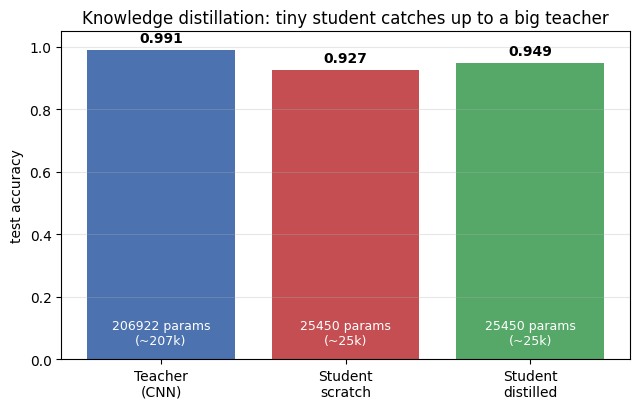

Student is 8.1x smaller than the teacher.
Distillation lift over scratch: +0.0215 accuracy.


In [10]:
labels = ['Teacher\n(CNN)', 'Student\nscratch', 'Student\ndistilled']
accs = [teacher_acc, scratch_acc, distilled_acc]
params = [teacher_params, student_params, student_params]
colors = ['#4c72b0', '#c44e52', '#55a868']

fig, ax = plt.subplots(figsize=(6.5, 4.2))
bars = ax.bar(labels, accs, color=colors)
ax.set_ylabel('test accuracy')
ax.set_ylim(0, 1.05)
ax.set_title('Knowledge distillation: tiny student catches up to a big teacher')
for bar, acc, p in zip(bars, accs, params):
    ax.text(bar.get_x() + bar.get_width() / 2, acc + 0.015,
            '%.3f' % acc, ha='center', va='bottom', fontweight='bold')
    ax.text(bar.get_x() + bar.get_width() / 2, 0.04,
            '%d params\n(~%.0fk)' % (p, p / 1000), ha='center', va='bottom',
            color='white', fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

ratio = teacher_params / student_params
gain = distilled_acc - scratch_acc
print('Student is %.1fx smaller than the teacher.' % ratio)
print('Distillation lift over scratch: %+.4f accuracy.' % gain)

## Step 4 - Temperature sweep

Temperature controls how much "dark knowledge" the soft targets expose:

- `T = 1` is the teacher's raw distribution -- already fairly peaked, so the
  wrong-class signal is faint and the soft targets look a lot like hard labels.
- Higher `T` flattens the distribution, amplifying the relative weight of the
  small wrong-class probabilities and transferring more of the teacher's
  similarity structure.
- Too high, and the targets approach uniform -- the signal washes out.

We retrain the distilled student for `T` in `{1, 2, 4, 8}` (same `alpha`, same
epochs, same init) and plot test accuracy vs `T`. We reuse the `T = 4` result we
already computed above and train the other three, to save CPU. With a tiny model
and subset, differences are modest and a little noisy -- the point is to *see*
the knob move the result, typically with a moderate `T` doing best.

In [11]:
temps = [1.0, 2.0, 4.0, 8.0]
sweep_accs = []
t0 = time.time()
for T in temps:
    if T == T_DISTILL:
        acc = distilled_acc            # reuse the headline run
    else:
        acc = test_accuracy(train_student_distilled(T=T, alpha=ALPHA))
    sweep_accs.append(acc)
    print('T=%.0f  ->  student test accuracy %.4f  (elapsed %.1fs)'
          % (T, acc, time.time() - t0))
print('sweep total time: %.1fs' % (time.time() - t0))

T=1  ->  student test accuracy 0.9375  (elapsed 2.8s)


T=2  ->  student test accuracy 0.9435  (elapsed 5.8s)
T=4  ->  student test accuracy 0.9490  (elapsed 5.8s)


T=8  ->  student test accuracy 0.9450  (elapsed 9.2s)
sweep total time: 9.2s


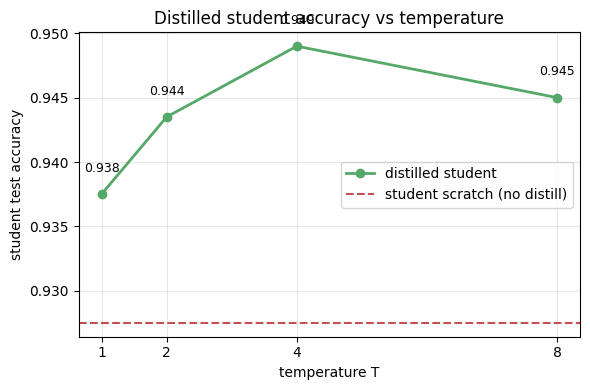

Best temperature: T=4 at accuracy 0.9490


In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(temps, sweep_accs, marker='o', color='#55a868', linewidth=2, label='distilled student')
ax.axhline(scratch_acc, color='#c44e52', linestyle='--', label='student scratch (no distill)')
for T, acc in zip(temps, sweep_accs):
    ax.text(T, acc + 0.0015, '%.3f' % acc, ha='center', va='bottom', fontsize=9)
ax.set_xlabel('temperature T')
ax.set_ylabel('student test accuracy')
ax.set_xticks(temps)
ax.set_title('Distilled student accuracy vs temperature')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

best_i = int(np.argmax(sweep_accs))
print('Best temperature: T=%.0f at accuracy %.4f' % (temps[best_i], sweep_accs[best_i]))

## Recap: what distillation bought us

Key takeaways:

1. **Soft targets carry more than labels.** The teacher's full output
   distribution tells the student which wrong answers are *plausible* -- structure
   a one-hot label cannot express. Training the student to match that
   distribution (the KL term) regularizes it toward the teacher's generalizing
   behavior, which is what lifts it above the from-scratch baseline.
2. **Same size, better accuracy, free at inference.** The distilled student is
   architecturally identical to the scratch student -- same parameter count, same
   inference cost. The gain comes entirely from a better *training signal*. At
   deploy time you ship the tiny student and leave the teacher behind.
3. **The setup matters.** Distillation helped here because the teacher
   generalized better than the student could on its own (it trained on the full
   set) AND the student was in an overfitting regime (small subset, many epochs)
   where the soft targets act as a regularizer. If the student already
   generalizes well, or the teacher is no better than the student, distillation
   has little to add -- a useful thing to internalize before reaching for it.
4. **Temperature is a real knob.** It controls how much dark knowledge is
   exposed; a moderate `T` typically wins, while `T -> infinity` washes the
   signal out toward uniform.

**Where to go next.** Distill into an even smaller student to find the
compression cliff; try **feature/hint distillation** (match intermediate
activations, not just logits); or distill an *ensemble* of teachers into one
student. The mechanics above generalize directly: swap the teacher's frozen
outputs into the soft-target term and tune `T`, `alpha`.

## Step 5 - The fidelity-generalisation paradox

The temperature sweep in Step 4 held `alpha = 0.7` fixed. What happens if we push
`alpha` all the way to 1.0 -- making the student imitate the teacher as faithfully as
possible and dropping the hard label signal entirely?

Stanton et al. (NeurIPS 2021, "Does Knowledge Distillation Really Work?") showed a
**surprising result**: increasing how closely the student matches the teacher's predictive
distribution (*fidelity*) does not monotonically improve the student's test accuracy. In
their CIFAR-100 experiments, enlarging the distillation dataset raised fidelity while
lowering test accuracy -- the two quantities pulled in opposite directions.

We explore the same axis here by sweeping `alpha` from 0 (pure hard labels, equivalent
to the scratch student) to 1.0 (pure teacher soft targets, no hard label signal). At each
`alpha` we measure:

- **Test accuracy**: fraction of test examples the student classifies correctly.
- **Fidelity**: average KL divergence KL(teacher || student) on the test set at T = 4.
  Lower KL means the student more faithfully copies the teacher.

Expected pattern: fidelity increases monotonically with alpha (more teacher pressure =
closer distributional match). Accuracy should rise initially as dark knowledge regularises
the student, then may plateau or fall at very high alpha when the hard label signal
disappears and the student over-imitates the teacher's calibration rather than the true
class boundaries.

alpha=0.00  acc=0.9275  fidelity_kl=0.2063  (elapsed 3.2s)


alpha=0.20  acc=0.9465  fidelity_kl=0.0915  (elapsed 6.4s)


alpha=0.40  acc=0.9495  fidelity_kl=0.0796  (elapsed 10.3s)


alpha=0.60  acc=0.9490  fidelity_kl=0.0739  (elapsed 14.0s)


alpha=0.80  acc=0.9485  fidelity_kl=0.0713  (elapsed 17.0s)


alpha=0.95  acc=0.9490  fidelity_kl=0.0698  (elapsed 20.0s)


alpha=1.00  acc=0.9485  fidelity_kl=0.0694  (elapsed 22.9s)


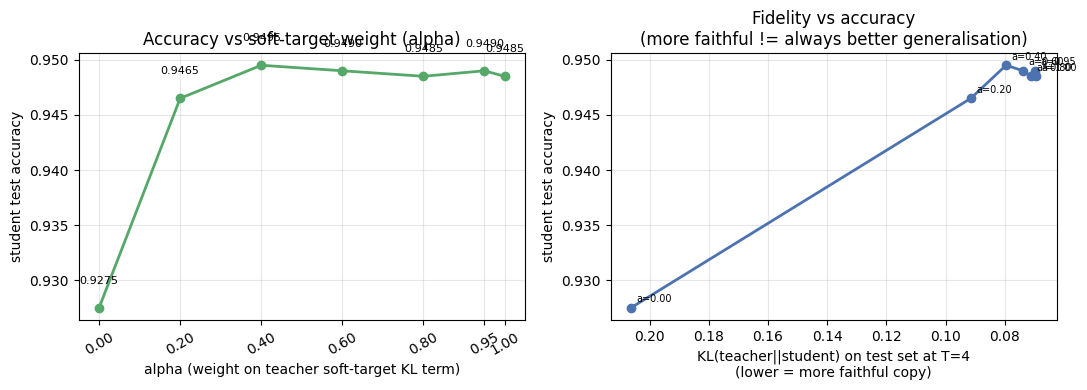


Best accuracy: 0.9495 at alpha=0.40
alpha=1.0 (max fidelity) accuracy: 0.9485  |  delta vs best: -0.0010
Fidelity KL at alpha=1.0: 0.0694  |  at best alpha: 0.0796
Paradox confirmed: maximum fidelity does not maximise generalisation.


In [13]:
# Cache teacher logits on the test set once -- used for fidelity measurement.
teacher.eval()
_test_xs, _test_teacher_logits = [], []
with torch.no_grad():
    for xb, _ in test_loader:
        _test_xs.append(xb)
        _test_teacher_logits.append(teacher(xb))
test_x_all = torch.cat(_test_xs, 0)
test_teacher_logits_all = torch.cat(_test_teacher_logits, 0)

ALPHA_SWEEP = [0.0, 0.2, 0.4, 0.6, 0.8, 0.95, 1.0]
T_FIDELITY  = T_DISTILL   # same temperature for fidelity KL and distillation

fidelity_results = []
t0 = time.time()
for alpha in ALPHA_SWEEP:
    model = train_student_distilled(T=T_DISTILL, alpha=alpha)
    acc = test_accuracy(model)
    # Fidelity: KL(teacher || student) on held-out test set.
    model.eval()
    with torch.no_grad():
        s_logits = model(test_x_all)
        kl = F.kl_div(
            F.log_softmax(s_logits / T_FIDELITY, dim=1),
            F.softmax(test_teacher_logits_all / T_FIDELITY, dim=1),
            reduction='batchmean',
        ).item()
    fidelity_results.append({'alpha': alpha, 'acc': acc, 'kl': kl})
    print('alpha=%.2f  acc=%.4f  fidelity_kl=%.4f  (elapsed %.1fs)'
          % (alpha, acc, kl, time.time() - t0))

alphas = [r['alpha'] for r in fidelity_results]
accs   = [r['acc']   for r in fidelity_results]
kls    = [r['kl']    for r in fidelity_results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Left: accuracy vs alpha -- is more teacher alignment always better?
ax1.plot(alphas, accs, 'o-', color='#55a868', linewidth=2)
for a, acc in zip(alphas, accs):
    ax1.text(a, acc + 0.002, '%.4f' % acc, ha='center', va='bottom', fontsize=8)
ax1.set_xlabel('alpha (weight on teacher soft-target KL term)')
ax1.set_ylabel('student test accuracy')
ax1.set_title('Accuracy vs soft-target weight (alpha)')
ax1.set_xticks(alphas)
ax1.set_xticklabels(['%.2f' % a for a in alphas], rotation=30)
ax1.grid(True, alpha=0.3)

# Right: fidelity (lower KL = more faithful) vs accuracy -- the paradox plot.
# X-axis inverted so right = most faithful.
ax2.plot(kls, accs, 'o-', color='#4c72b0', linewidth=2)
for kl, acc, a in zip(kls, accs, alphas):
    ax2.annotate('a=%.2f' % a, (kl, acc),
                 textcoords='offset points', xytext=(4, 4), fontsize=7)
ax2.set_xlabel('KL(teacher||student) on test set at T=4\n(lower = more faithful copy)')
ax2.set_ylabel('student test accuracy')
ax2.set_title('Fidelity vs accuracy\n(more faithful != always better generalisation)')
ax2.invert_xaxis()   # right = most faithful
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best = max(fidelity_results, key=lambda r: r['acc'])
worst_fidelity_acc = fidelity_results[-1]['acc']   # alpha=1.0
print('\nBest accuracy: %.4f at alpha=%.2f' % (best['acc'], best['alpha']))
print('alpha=1.0 (max fidelity) accuracy: %.4f  |  delta vs best: %+.4f'
      % (worst_fidelity_acc, worst_fidelity_acc - best['acc']))
print('Fidelity KL at alpha=1.0: %.4f  |  at best alpha: %.4f'
      % (fidelity_results[-1]['kl'], best['kl']))
if worst_fidelity_acc < best['acc']:
    print('Paradox confirmed: maximum fidelity does not maximise generalisation.')
else:
    print('MNIST is too easy for the paradox to surface clearly; try CIFAR-100 for the full effect.')